In [2]:
import pandas as pd

In [3]:
!pip install plotly


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
trades_0 = pd.read_csv('trades_round_0_day_-2.csv', delimiter = ';')
trades_1 = pd.read_csv('trades_round_0_day_-1.csv', delimiter = ';')
order_book_0 = pd.read_csv('prices_round_0_day_-2.csv', delimiter = ';')
order_book_1 = pd.read_csv('prices_round_0_day_-1.csv', delimiter = ';')

In [5]:
trades_0.head()

,timestamp,buyer,seller,symbol,currency,price,quantity
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5


In [6]:
order_book_0_tomatoes = order_book_0[order_book_0['product'] == 'TOMATOES']
order_book_0_emeralds = order_book_0[order_book_0['product'] == 'EMERALDS']
trades_0_tomatoes = trades_0.query('symbol == "TOMATOES"')
trades_0_emeralds = trades_0.query('symbol == "EMERALDS"')


In [7]:
order_book_1_tomatoes = order_book_1[order_book_1['product'] == 'TOMATOES']
order_book_1_emeralds = order_book_1[order_book_1['product'] == 'EMERALDS']
trades_1_tomatoes = trades_1.query('symbol == "TOMATOES"')
trades_1_emeralds = trades_1.query('symbol == "EMERALDS"')


order_book_1_tomatoes['timestamp'] += 1000000
order_book_1_emeralds['timestamp'] += 1000000
trades_1_tomatoes['timestamp'] += 1000000
trades_1_emeralds['timestamp'] += 1000000

In [8]:
order_book_tomatoes = pd.concat([order_book_0_tomatoes, order_book_1_tomatoes])
order_book_emeralds = pd.concat([order_book_0_emeralds, order_book_1_emeralds])
trades_tomatoes = pd.concat([trades_0_tomatoes, trades_1_tomatoes])
trades_emeralds = pd.concat([trades_0_emeralds, trades_1_emeralds])

In [9]:
order_book_tomatoes = order_book_tomatoes.reset_index(drop = True)
order_book_emeralds = order_book_emeralds.reset_index(drop = True)
trades_tomatoes = trades_tomatoes.reset_index(drop = True)
trades_emeralds = trades_emeralds.reset_index(drop = True)

In [10]:
order_book_tomatoes.query("day == -1").tail()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
19995,-1,1999500,TOMATOES,4955,5,4950,10,4948.0,23.0,4963,10,4964,23,NaN,NaN,4959.0,0.0
19996,-1,1999600,TOMATOES,4955,5,4949,6,4948.0,18.0,4963,6,4964,18,NaN,NaN,4959.0,0.0
19997,-1,1999700,TOMATOES,4950,10,4948,16,NaN,NaN,4963,10,4964,16,NaN,NaN,4956.5,0.0
19998,-1,1999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0
19999,-1,1999900,TOMATOES,4950,10,4949,25,NaN,NaN,4964,10,4965,25,NaN,NaN,4957.0,0.0


In [11]:
trades_tomatoes.tail()

,timestamp,buyer,seller,symbol,currency,price,quantity
815,1979000,NaN,NaN,TOMATOES,XIRECS,4965.0,5
816,1982500,NaN,NaN,TOMATOES,XIRECS,4950.0,3
817,1985100,NaN,NaN,TOMATOES,XIRECS,4946.0,2
818,1993000,NaN,NaN,TOMATOES,XIRECS,4956.0,2
819,1995600,NaN,NaN,TOMATOES,XIRECS,4958.0,3


In [12]:
trades_0.shape

(588, 7)

In [13]:
import plotly.graph_objects as go

def plot_interval(order_book, trades, t0, t1):
    curr_order_book = order_book.iloc[t0:t1]
    idx = curr_order_book["timestamp"]

    t_min = idx.min()
    t_max = idx.max()

    # filter trades to same time window
    curr_trades = trades[
        (trades["timestamp"] >= t_min) &
        (trades["timestamp"] <= t_max)
    ]

    fig = go.Figure()

    # --- mid ---
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["mid_price"],
        name="mid",
        line=dict(width=3)
    ))

    # --- bids ---
    fig.add_trace(go.Scatter(x=idx, y=curr_order_book["bid_price_1"], name="bid_price_1"))
    fig.add_trace(go.Scatter(x=idx, y=curr_order_book["bid_price_2"], name="bid_price_2"))
    fig.add_trace(go.Scatter(x=idx, y=curr_order_book["bid_price_3"], name="bid_price_3"))

    # --- asks ---
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["ask_price_1"],
        name="ask_price_1",
        line=dict(dash="dash")
    ))
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["ask_price_2"],
        name="ask_price_2",
        line=dict(dash="dash")
    ))
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["ask_price_3"],
        name="ask_price_3",
        line=dict(dash="dash")
    ))

    # --- trades ---
    # --- trades ---
    if not curr_trades.empty:
        mid_series = curr_order_book.set_index("timestamp")["mid_price"]

        # align mid prices to trade timestamps (positional)
        trade_mid = mid_series.reindex(curr_trades["timestamp"], method="nearest").to_numpy()

        trade_prices = curr_trades["price"].to_numpy()

        # infer direction
        colors = ["green" if p > m else "red" for p, m in zip(trade_prices, trade_mid)]

        # scale sizes
        sizes = curr_trades["quantity"].to_numpy()
        sizes = 5 + 15 * (sizes / sizes.max())

        fig.add_trace(go.Scatter(
            x=curr_trades["timestamp"],
            y=curr_trades["price"],
            mode="markers",
            name="trades",
            customdata=curr_trades["quantity"],
            marker=dict(
                size=sizes,
                color=colors,
                opacity=0.6,
                line=dict(width=1)
            ),
            hovertemplate=
                "Price: %{y}<br>" +
                "Quantity: %{customdata}<br>" +
                "Time: %{x}<extra></extra>"
        ))

    fig.update_layout(
        title="orderbook + trades (size encoded)",
        xaxis_title="timestamp",
        yaxis_title="price",
        legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
        margin=dict(r=150)
    )

    fig.show(renderer="browser")


    # --- spread plot ---
    spread_fig = go.Figure()
    spread = curr_order_book["ask_price_1"] - curr_order_book["bid_price_1"]

    spread_fig.add_trace(go.Scatter(
        x=idx, y=spread,
        name="bid-ask spread",
        line=dict(width=2)
    ))

    spread_fig.update_layout(
        title="bid-ask spread over interval",
        xaxis_title="timestamp",
        yaxis_title="spread"
    )

    spread_fig.show(renderer="browser")

In [14]:
order_book_tomatoes.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
1,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
2,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
3,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0
4,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0


In [15]:
plot_interval(order_book_tomatoes, trades_tomatoes, 0, 20000)

In [12]:
trades_tomatoes[trades_tomatoes['quantity'] == 6].head()

,timestamp,buyer,seller,symbol,currency,price,quantity
354,896700,NaN,NaN,TOMATOES,XIRECS,5031.0,6
573,1400200,NaN,NaN,TOMATOES,XIRECS,4991.0,6


In [36]:
order_book_tomatoes['bid_diff'] = order_book_tomatoes['bid_price_1'].diff()
order_book_tomatoes['ask_diff'] = order_book_tomatoes['ask_price_1'].diff()

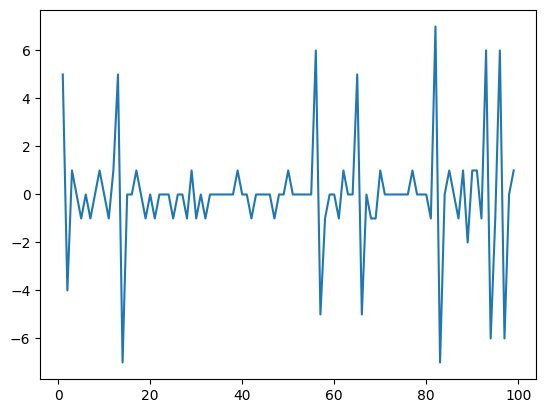

In [38]:
import matplotlib.pyplot as plt
plt.plot(order_book_tomatoes['bid_diff'][0:100])

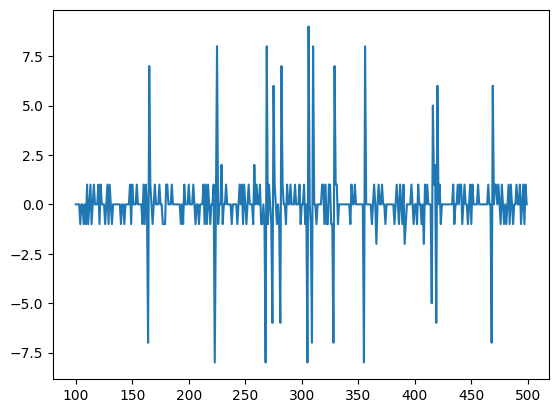

In [40]:
plt.plot(order_book_tomatoes['ask_diff'][100:500])